Model Training

1.1 Import Data and Required Packages
    - Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [22]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

Import the CSV Data as Pandas DataFrame

In [7]:
df = pd.read_csv('../artifacts/raw.csv')
df = df.drop(columns=['Unnamed: 0'])

In [8]:
df.head

<bound method NDFrame.head of      gender race_ethnicity parental_level_of_education         lunch  \
0    female        group D             master's degree      standard   
1    female        group C           bachelor's degree  free/reduced   
2    female        group D                some college  free/reduced   
3      male        group C             master's degree  free/reduced   
4      male        group E                 high school      standard   
..      ...            ...                         ...           ...   
995  female        group D                 high school  free/reduced   
996    male        group E          associate's degree      standard   
997  female        group B                some college  free/reduced   
998  female        group C          associate's degree      standard   
999  female        group D            some high school      standard   

    test_preparation_course  math_score  reading_score  writing_score  
0                      none      

Preparing X and Y variables

In [9]:
X = df.drop(columns=['math_score'],axis=1)
# Maths score is going to be our output feature

In [10]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group D,master's degree,standard,none,70,75
1,female,group C,bachelor's degree,free/reduced,completed,83,83
2,female,group D,some college,free/reduced,none,89,86
3,male,group C,master's degree,free/reduced,none,67,66
4,male,group E,high school,standard,none,64,57


In [12]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group D' 'group C' 'group E' 'group B' 'group A']
Categories in'parental level of education' variable: ["master's degree" "bachelor's degree" 'some college' 'high school'
 "associate's degree" 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [13]:
y = df['math_score']

In [14]:
y

0      62
1      66
2      79
3      61
4      73
       ..
995    52
996    62
997    74
998    65
999    61
Name: math_score, Length: 1000, dtype: int64

In [15]:
# Create Column Transformer with 3 types of transformers
# Differentiating the categorical and numerical features
num_features = X.select_dtypes(exclude="object").columns # Numerical
cat_features = X.select_dtypes(include="object").columns # Categorical

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
# OneHotEncoder helps changing categorical features into numerical features
# StandardScalar is for to scale down the numerical features
# So to use above 2 together we need ColumnTransfer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [16]:
X = preprocessor.fit_transform(X)

In [17]:
X.shape

(1000, 19)

In [18]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))


Create an Evaluate Function to give all metrics after model Training

In [19]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [24]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3984
- Mean Absolute Error: 4.2968
- R2 Score: 0.8773
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.0640
- Mean Absolute Error: 4.0539
- R2 Score: 0.8708


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.6595
- Mean Absolute Error: 5.2600
- R2 Score: 0.8133
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.9043
- Mean Absolute Error: 4.6669
- R2 Score: 0.8244


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3987
- Mean Absolute Error: 4.2953
- R2 Score: 0.8773
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.0617
- Mean Absolute Error: 4.0536
- R2 Score: 0.8709


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.9286
- Mean Absolute Error: 4.6980
- R2 Score: 0.8520
-----------------------

In [25]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.870932
0,Linear Regression,0.870813
7,CatBoosting Regressor,0.839700
5,Random Forest Regressor,0.832062
1,Lasso,0.824385
8,AdaBoost Regressor,0.812786
6,XGBRegressor,0.796508
3,K-Neighbors Regressor,0.768953
4,Decision Tree,0.644518


Linear Regression

In [26]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 87.08


Plot y_pred and y_test

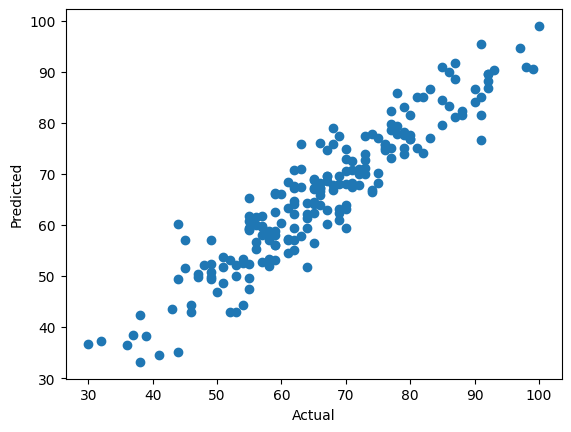

In [27]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

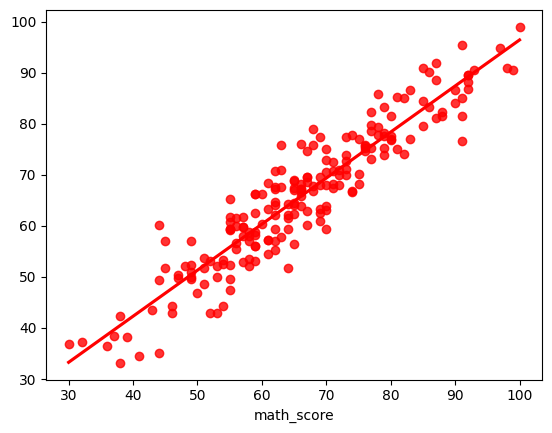

In [28]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

Difference between Actual and Predicted Values

In [29]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,55,61.687607,-6.687607
737,57,59.702923,-2.702923
740,39,38.278179,0.721821
660,71,70.854810,0.145190
411,56,56.626096,-0.626096
...,...,...,...
408,37,38.483609,-1.483609
332,58,52.061391,5.938609
208,77,73.183127,3.816873
613,86,83.322483,2.677517
